# Data preparation for the two-stage classifier

This notebook reshapes the cleaned dataset into train/test splits and binary-label versions for **two competing pipeline architectures**:

- **Architecture A (standard)**: Stage 1A — ham vs not_normal → Stage 2A — spam vs phishing
- **Architecture B (phishing-first)**: Stage 1B — phishing vs not_phishing → Stage 2B — ham vs spam

All output files go to `data/processed/07/` to keep the top-level directory clean.

Input: `data/processed/cleaned_messages.csv` (produced by `notebooks/01_data_preprocessing.ipynb`).

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

BASE = "../.."

In [12]:
df = pd.read_csv(f"{BASE}/data/processed/cleaned_messages.csv")
print(df.shape)
df["label"].value_counts()

(509384, 2)


label
spam        250274
ham         173276
phishing     85834
Name: count, dtype: int64

In [13]:
# stratified split — same random_state used throughout for reproducibility
train, test = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=27)
train = train.reset_index(drop=True)
test  = test.reset_index(drop=True)

print("train:", train["label"].value_counts().to_dict())
print("test: ", test["label"].value_counts().to_dict())

train: {'spam': 200219, 'ham': 138621, 'phishing': 68667}
test:  {'spam': 50055, 'ham': 34655, 'phishing': 17167}


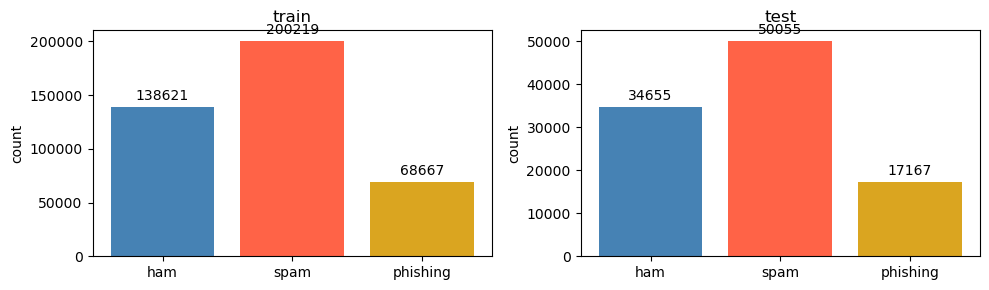

In [14]:
# quick look at class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, df_part, title in zip(axes, [train, test], ["train", "test"]):
    counts = df_part["label"].value_counts().reindex(["ham", "spam", "phishing"])
    bars = ax.bar(counts.index, counts.values, color=["steelblue", "tomato", "goldenrod"])
    ax.bar_label(bars, fmt="%d", padding=3)
    ax.set_title(title)
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## Stage 1A labels

Architecture A's first stage asks "is this message suspicious or not?". Spam and phishing get merged into `not_normal`. Any phishing message called `normal` here never reaches Stage 2A — it silently becomes a ham prediction.

In [15]:
label_map_a = {"ham": "normal", "spam": "not_normal", "phishing": "not_normal"}

stage1a_train = train.copy()
stage1a_train["label"] = stage1a_train["label"].map(label_map_a)

stage1a_test = test.copy()
stage1a_test["label"] = stage1a_test["label"].map(label_map_a)

print("Stage 1A train:", stage1a_train["label"].value_counts().to_dict())

Stage 1A train: {'not_normal': 268886, 'normal': 138621}


## Stage 1B labels

Architecture B's first stage asks "is this message phishing or not?". Ham and spam are merged into `not_phishing`. Phishing makes up only ~16% of the training set, making this a harder imbalance than Stage 1A (~34% normal).

In [16]:
label_map_b = {"phishing": "phishing", "ham": "not_phishing", "spam": "not_phishing"}

stage1b_train = train.copy()
stage1b_train["label"] = stage1b_train["label"].map(label_map_b)

stage1b_test = test.copy()
stage1b_test["label"] = stage1b_test["label"].map(label_map_b)

print("Stage 1B train:", stage1b_train["label"].value_counts().to_dict())

Stage 1B train: {'not_phishing': 338840, 'phishing': 68667}


## Stage 2A labels

Stage 2A only sees spam and phishing — the messages Stage 1A flagged as suspicious. Ham rows are excluded.

In [17]:
stage2a_train = train[train["label"].isin(["spam", "phishing"])].copy().reset_index(drop=True)
stage2a_test  = test[test["label"].isin(["spam", "phishing"])].copy().reset_index(drop=True)

print("Stage 2A train:", stage2a_train["label"].value_counts().to_dict())
print("Stage 2A test: ", stage2a_test["label"].value_counts().to_dict())

Stage 2A train: {'spam': 200219, 'phishing': 68667}
Stage 2A test:  {'spam': 50055, 'phishing': 17167}


## Stage 2B labels

Stage 2B only sees ham and spam — the messages Stage 1B didn't call phishing. Phishing rows are excluded.

In [18]:
stage2b_train = train[train["label"].isin(["ham", "spam"])].copy().reset_index(drop=True)
stage2b_test  = test[test["label"].isin(["ham", "spam"])].copy().reset_index(drop=True)

print("Stage 2B train:", stage2b_train["label"].value_counts().to_dict())
print("Stage 2B test: ", stage2b_test["label"].value_counts().to_dict())

Stage 2B train: {'spam': 200219, 'ham': 138621}
Stage 2B test:  {'spam': 50055, 'ham': 34655}


In [19]:
os.makedirs(f"{BASE}/data/processed/07", exist_ok=True)

train.to_csv(f"{BASE}/data/processed/07/train_data.csv",   index=False)
test.to_csv(f"{BASE}/data/processed/07/test_data.csv",    index=False)

stage1a_train.to_csv(f"{BASE}/data/processed/07/stage1a_train.csv", index=False)
stage1a_test.to_csv(f"{BASE}/data/processed/07/stage1a_test.csv",  index=False)
stage1b_train.to_csv(f"{BASE}/data/processed/07/stage1b_train.csv", index=False)
stage1b_test.to_csv(f"{BASE}/data/processed/07/stage1b_test.csv",  index=False)
stage2a_train.to_csv(f"{BASE}/data/processed/07/stage2a_train.csv", index=False)
stage2a_test.to_csv(f"{BASE}/data/processed/07/stage2a_test.csv",  index=False)
stage2b_train.to_csv(f"{BASE}/data/processed/07/stage2b_train.csv", index=False)
stage2b_test.to_csv(f"{BASE}/data/processed/07/stage2b_test.csv",  index=False)

print("saved 10 files to data/processed/07/")

saved 10 files to data/processed/07/
